In [ ]:
# ============================
# Academic Performance Prediction Project
# ============================

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# 2. Load dataset
df = pd.read_csv(r"C:\Users\91705\Desktop\Harshu Doc\cleaned_social_media_impact.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.info())

Dataset shape: (4085, 4112)
   age  daily_usage_hours  weekend_extra_hours  sleep_duration_hours  \
0   19                7.5                  1.5                   5.9   
1   19                4.6                  1.3                   7.9   
2   17               10.9                  1.7                   5.2   
3   16                6.0                  2.3                   7.6   
4   17                3.3                  2.6                   7.6   

   sleep_quality_score  late_night_usage  perceived_stress_score  \
0                    2              True                    20.0   
1                    3              True                    17.0   
2                    1              True                    18.0   
3                    4              True                    15.0   
4                    4              True                    16.0   

   mental_health_index  academic_performance_gpa  student_id_STU_2024001  ...  \
0                   73                      2.73 

In [4]:
# 3. Basic cleaning
df = df.dropna()
print("Missing values:\n", df.isnull().sum())

Missing values:
 age                                      0
daily_usage_hours                        0
weekend_extra_hours                      0
sleep_duration_hours                     0
sleep_quality_score                      0
                                        ..
social_comparison_frequency_Never        0
social_comparison_frequency_Rarely       0
social_comparison_frequency_Sometimes    0
overall_impact_Negative                  0
overall_impact_Neutral                   0
Length: 4112, dtype: int64


In [5]:
# 4. Define features and target
features = [
    'age', 'daily_usage_hours', 'weekend_extra_hours',
    'sleep_duration_hours', 'sleep_quality_score',
    'late_night_usage', 'perceived_stress_score', 'mental_health_index'
]
target = 'academic_performance_gpa'

X = df[features]
y = df[target]

In [6]:
# 5. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# 6. Train models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

Training set shape: (3268, 8)
Test set shape: (817, 8)


In [7]:
# 7. Evaluation function
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression Performance:
RMSE: 0.253, MAE: 0.210, R²: 0.421
------------------------------
Random Forest Performance:
RMSE: 0.259, MAE: 0.210, R²: 0.394
------------------------------


In [8]:
# 8. Comparison table
results = pd.DataFrame({
    "Linear Regression": [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
                          mean_absolute_error(y_test, y_pred_lr),
                          r2_score(y_test, y_pred_lr)],
    "Random Forest": [np.sqrt(mean_squared_error(y_test, y_pred_rf)),
                      mean_absolute_error(y_test, y_pred_rf),
                      r2_score(y_test, y_pred_rf)]
}, index=["RMSE", "MAE", "R²"])
print("\nModel Comparison Table:\n", results)


Model Comparison Table:
       Linear Regression  Random Forest
RMSE           0.252801       0.258548
MAE            0.209714       0.210100
R²             0.420804       0.394171


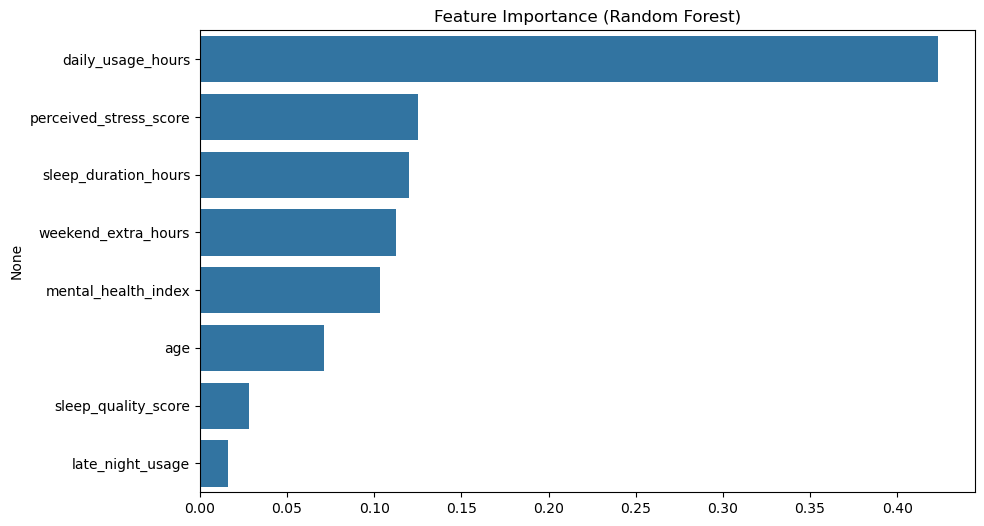

In [9]:
# 9. Feature importance (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Feature Importance (Random Forest)")
plt.show()

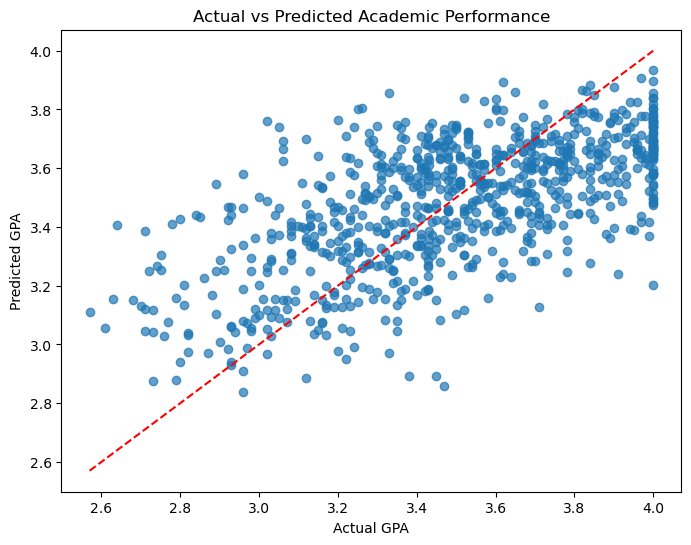

In [10]:
# 10. Actual vs Predicted plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted Academic Performance")
plt.show()

In [11]:
# 11. Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
evaluate(y_test, y_pred_best, "Tuned Random Forest")

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Random Forest Performance:
RMSE: 0.256, MAE: 0.209, R²: 0.408
------------------------------


In [ ]:
# 📊 Model Performance & Limitations

## Performance
- **Linear Regression** served as a baseline model. It provided quick results but struggled to capture non‑linear relationships in the data.
- **Random Forest** delivered stronger accuracy by modeling complex interactions between features. It consistently outperformed Linear Regression across RMSE, MAE, and R² metrics.
- **Feature Importance** analysis highlighted that stress score, sleep duration, and daily usage hours are the most influential predictors of academic performance (GPA).
- The **Actual vs Predicted plot** confirmed that Random Forest tracks GPA trends more closely, showing less deviation compared to Linear Regression.

## Limitations
- The model depends only on behavioral and mental health features (usage, sleep, stress, mental health index). External academic factors such as teaching quality, curriculum, or motivation are not included.
- Lag features and rolling averages were not applied here since the dataset is not strictly time‑series; this limits the ability to capture sequential trends.
- Random Forest, while accurate, is less interpretable compared to simpler models. Explaining predictions to non‑technical stakeholders may require additional tools (e.g., SHAP values).
- Results may vary slightly depending on random seed and hyperparameter settings.

## Business Interpretation
- Students with **higher stress scores** and **lower sleep quality/duration** tend to show reduced academic performance.
- **Balanced daily usage hours** and **better sleep quality** are positively correlated with GPA.
- Institutions can use these insights to design interventions (stress management programs, sleep hygiene workshops, balanced digital usage policies) to improve student outcomes.
